In [30]:
import matplotlib.pyplot as plt
import pandas as pd, numpy as np

In [32]:
df = pd.read_csv('temperature_belgium_yearly.csv')

df = df[df['year']>=2020]

      ssp  year       mean        min        max
0  ssp126  2020  11.192675   9.800710  11.800748
1  ssp126  2021  11.421405  10.644352  13.063296
2  ssp126  2022  11.468669  10.718084  12.201847
3  ssp126  2023  11.110004  10.344373  11.429130
4  ssp126  2024  11.375334  10.632108  12.003452


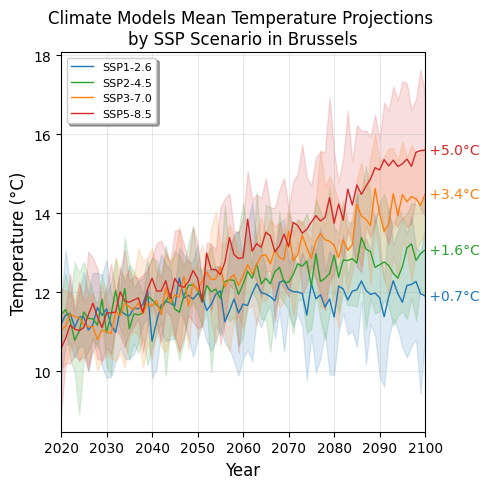

In [64]:
# Calculate mean, min, and max for each ssp-year combination
stats_df = df.groupby(['ssp', 'year'])['avg'].agg(['mean', 'min', 'max']).reset_index()
print(stats_df.head())

plt.figure(figsize=(5, 5))

# Enhanced color palette
colors = {
    'ssp126': '#1f77b4',  # blue
    'ssp245': '#2ca02c',  # green
    'ssp370': '#ff7f0e',  # orange
    'ssp585': '#d62728'   # red
}

ssp_labels = {
    'ssp126': 'SSP1-2.6',
    'ssp245': 'SSP2-4.5', 
    'ssp370': 'SSP3-7.0',
    'ssp585': 'SSP5-8.5'
}

for ssp in stats_df['ssp'].unique():
    ssp_data = stats_df[stats_df['ssp'] == ssp].sort_values('year')
    
    # Plot shaded area (min to max)
    plt.fill_between(ssp_data['year'], ssp_data['min'], ssp_data['max'],
                     color=colors[ssp], alpha=0.15)
    
    # Plot mean line
    plt.plot(ssp_data['year'], ssp_data['mean'], 
             color=colors[ssp], linewidth=1.0, 
             label=ssp_labels.get(ssp, ssp) #, marker='o', markersize=4
            )
    
    evol = ssp_data['mean'].iloc[-1] - ssp_data['mean'].iloc[0]
    # Annotation using axis coordinates (0-1 relative to plot area)
    plt.annotate(f" +{np.round(evol,1)}°C", 
                xy=(2100, ssp_data['mean'].iloc[-1]), xycoords='data',
                fontsize=10, ha='left', va='center',
                 color = colors[ssp])

plt.xlabel('Year', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.title('Climate Models Mean Temperature Projections \nby SSP Scenario in Brussels', fontsize=12)
plt.legend(fontsize=8, frameon=True, fancybox=True, shadow=True)
plt.grid(True, alpha=0.3)
plt.xlim(2020,2100)
plt.tight_layout()
plt.savefig('Temperature Evolution Belgium.pdf')

In [22]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.
